# Задача 2 — Анализ отзывов: выбор, обучение и сравнение нейросетевых архитектур
### Групповой проект №5 · Deep Learning · НИУ ВШЭ БИ

**Бизнес-задача.** Превратить текст отзыва в структурный сигнал — **тональность** (negative / neutral
/ positive). Это ядро деливераблов Задачи 2: аспектная тональность, детектор расхождения «текст↔оценка»
и оценка заметок (tips) без звёзд. Метку берём из `stars` (1–2 → neg, 3 → neu, 4–5 → pos) — звезда
выступает «бесплатной» разметкой (см. `02_eda_slice.ipynb`).

**DL-постановка.** Классификация текста на 3 класса. Сравниваем **три значимо разные архитектуры**
по нарастанию индуктивного смысла и ёмкости:

| Архитектура | Что моделирует | Почему включена |
|---|---|---|
| **TextCNN** (Kim, 2014) | локальные n-граммы (ключевые фразы «not good», «highly recommend») | быстрый и сильный baseline свёрток на тексте |
| **BiLSTM** | последовательные/двунаправленные зависимости, порядок слов | рекуррентная сеть — классика для текста |
| **DistilBERT** (fine-tune) | контекстные представления + перенос знаний (pretrain) | трансформер вне рамок лекций: subword-токенизация, self-attention, предобученные веса |

Все три обучаются на **одних и тех же** данных/разбиении, с одной функцией потерь (взвешенной по
классам — из-за дисбаланса ~5.8×, см. EDA), и сравниваются по **macro-F1** (устойчиво к дисбалансу),
accuracy, F1 по классам, числу параметров и времени обучения.

> Тяжёлые флаги управляются через `.env`: `ENABLE_ARTIFACTS` (сохранять графики/чекпойнты в
> `artifacts/`), `ENABLE_LOGGING` (писать метрики ранов в `reports/runs/`). По умолчанию — выкл.

In [ ]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # неподдержанные на MPS операции -> CPU
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import sys, json, time, re, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

_PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_PROJECT))
from _constants import REVIEWS_PARQUET, ARTIFACTS, REPORTS, ENABLE_ARTIFACTS, ENABLE_LOGGING, ENABLE_FAST_DEV_RUN

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

SMOKE = ENABLE_FAST_DEV_RUN
SAMPLE_TOTAL    = 1500 if SMOKE else 40_000   # сабсэмпл (стратифицир. сплит 80/10/10)
MAXLEN          = 64   if SMOKE else 200      # max длина для CNN/LSTM (из EDA ~95-й перц.)
CNN_LSTM_EPOCHS = 1    if SMOKE else 5
CNN_LSTM_BS     = 128
EMB_DIM         = 128
BERT_NAME       = "distilbert-base-uncased"
BERT_TRAIN_CAP  = 300  if SMOKE else 15_000   # fine-tune трансформера дороже -> ограничиваем train
BERT_EPOCHS     = 1    if SMOKE else 2
BERT_BS         = 16   if SMOKE else 32
BERT_MAXLEN     = 64   if SMOKE else 160
LABELS = ["negative", "neutral", "positive"]

NB = "Task2"
def savefig(name):
    if not ENABLE_ARTIFACTS:
        return
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    plt.tight_layout(); plt.savefig(ARTIFACTS / f"{NB}_{name}.png", bbox_inches="tight", dpi=140)

print("device:", device, "| SMOKE:", SMOKE, "| torch:", torch.__version__)

device: mps | SMOKE: False | torch: 2.12.0


## 1. Данные и разбиение

Грузим текст + оценку из среза, строим 3-классовую метку, берём стратифицированный сабсэмпл
(для разумного времени обучения — размер задаётся `SAMPLE_TOTAL`, пайплайн масштабируется) и делим
на train/val/test 80/10/10 со стратификацией по классу.

In [2]:
# !!!!!!!! ДИСБАЛАНС: веса классов !!!!!!!!
df = pd.read_parquet(REVIEWS_PARQUET, columns=["text", "stars"]).dropna(subset=["text"])
df = df[df["text"].str.len() > 0].copy()
df["label"] = np.where(df["stars"] <= 2, 0, np.where(df["stars"] == 3, 1, 2)).astype(int)

n = min(SAMPLE_TOTAL, len(df))
df = df.sample(n, random_state=SEED).reset_index(drop=True)

train_df, tmp = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(tmp, test_size=0.5, stratify=tmp["label"], random_state=SEED)

counts = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor((counts.sum() / (len(counts) * counts)).values, dtype=torch.float32)

print(f"train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}")
print("распределение классов (train):", dict(zip(LABELS, counts.values)))
print("веса классов:", {l: round(float(w), 2) for l, w in zip(LABELS, class_weights)})

train=32,000  val=4,000  test=4,000
распределение классов (train): {'negative': np.int64(7786), 'neutral': np.int64(3080), 'positive': np.int64(21134)}
веса классов: {'negative': 1.37, 'neutral': 3.46, 'positive': 0.5}


## 2. Токенизация и словарь (для TextCNN и BiLSTM)

Простой регэксп-токенайзер (слова из букв, нижний регистр), словарь строится **только по train**
(во избежание утечки), редкие слова → `<unk>`, паддинг → `<pad>`.

In [3]:
TOKEN_RE = re.compile(r"[a-z]+")
def tokenize(t): return TOKEN_RE.findall(str(t).lower())

MIN_FREQ = 2
cnt = Counter()
for t in train_df["text"]:
    cnt.update(tokenize(t))
itos = ["<pad>", "<unk>"] + [w for w, c in cnt.items() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB = len(itos)
PAD_IDX = 0
MIN_LEN = 5  # >= макс. размера свёрточного ядра

def encode(t):
    return [stoi.get(w, 1) for w in tokenize(t)][:MAXLEN]

class TextDS(Dataset):
    def __init__(self, texts, labels):
        self.x = [encode(t) for t in texts]
        self.y = list(labels)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

def collate(batch):
    xs, ys = zip(*batch)
    maxlen = max(MIN_LEN, max(len(x) for x in xs))
    out = torch.zeros(len(xs), maxlen, dtype=torch.long)
    for i, x in enumerate(xs):
        if x: out[i, :len(x)] = torch.tensor(x, dtype=torch.long)
    return out, torch.tensor(ys, dtype=torch.long)

def make_loader(d, bs, shuffle):
    return DataLoader(TextDS(d["text"].tolist(), d["label"].tolist()),
                      batch_size=bs, shuffle=shuffle, collate_fn=collate)

tr_loader = make_loader(train_df, CNN_LSTM_BS, True)
va_loader = make_loader(val_df,   CNN_LSTM_BS, False)
te_loader = make_loader(test_df,  CNN_LSTM_BS, False)
print(f"Размер словаря: {VOCAB:,}")

Размер словаря: 24,872


## 3. Архитектуры

- **TextCNN** — эмбеддинги → параллельные свёртки с ядрами 3/4/5 (n-граммы) → max-pool-over-time →
  конкатенация → dropout → линейный классификатор.
- **BiLSTM** — эмбеддинги → двунаправленный LSTM → конкатенация последних скрытых состояний
  (вперёд+назад) → dropout → линейный слой.

In [4]:
class TextCNN(nn.Module):
    def __init__(self, vocab, emb=EMB_DIM, n_filters=100, ks=(3, 4, 5), n_cls=3, drop=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.convs = nn.ModuleList([nn.Conv1d(emb, n_filters, k) for k in ks])
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(n_filters * len(ks), n_cls)
    def forward(self, x):
        e = self.emb(x).transpose(1, 2)                       # B,E,T
        feats = [torch.relu(c(e)).max(dim=2).values for c in self.convs]
        return self.fc(self.drop(torch.cat(feats, dim=1)))

class BiLSTM(nn.Module):
    def __init__(self, vocab, emb=EMB_DIM, hid=128, n_cls=3, drop=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(hid * 2, n_cls)
    def forward(self, x):
        e = self.emb(x)
        _, (h, _) = self.lstm(e)
        h = torch.cat([h[-2], h[-1]], dim=1)                 # последние fwd & bwd
        return self.fc(self.drop(h))

def n_params(m): return sum(p.numel() for p in m.parameters())

## 4. Общий цикл обучения

Единый цикл для всех моделей: AdamW, взвешенная по классам кросс-энтропия, метрики **в разрезе эпох**
(train/val loss, val accuracy, val macro-F1). Берём веса лучшей по val-F1 эпохи. Для DistilBERT —
меньший lr (2e-5) и батчи токенайзера HF.

In [5]:
# !!!!!!!! ДИСБАЛАНС: взвешенный лосс + macro-F1 !!!!!!!!
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

def _step(model, batch, bert):
    if bert:
        ids, am, y = (t.to(device) for t in batch)
        logits = model(input_ids=ids, attention_mask=am).logits
    else:
        x, y = batch
        logits = model(x.to(device)); y = y.to(device)
    return logits, y

def run_epoch(model, loader, train, opt, bert=False):
    model.train() if train else model.eval()
    tot = loss_sum = 0; preds = []; gts = []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            logits, y = _step(model, batch, bert)
            loss = loss_fn(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item() * len(y); tot += len(y)
            preds += logits.argmax(1).tolist(); gts += y.tolist()
    return loss_sum / tot, accuracy_score(gts, preds), f1_score(gts, preds, average="macro"), preds, gts

def train_model(name, model, tr, va, epochs, lr, bert=False):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    hist, best_f1, best_state = [], -1.0, None
    t0 = time.time()
    for ep in range(1, epochs + 1):
        te0 = time.time()
        trl, tra, trf, *_ = run_epoch(model, tr, True, opt, bert)
        vll, vaa, vaf, *_ = run_epoch(model, va, False, opt, bert)
        hist.append({"epoch": ep, "train_loss": trl, "val_loss": vll, "val_acc": vaa, "val_macro_f1": vaf})
        if vaf > best_f1:
            best_f1 = vaf
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  [{name}] ep{ep}/{epochs} train_loss={trl:.3f} val_loss={vll:.3f} "
              f"val_acc={vaa:.3f} val_f1={vaf:.3f} ({time.time()-te0:.0f}s)")
    if best_state: model.load_state_dict(best_state)
    return hist, time.time() - t0

@torch.no_grad()
def evaluate(model, loader, bert=False):
    model.eval(); preds = []; gts = []
    for batch in loader:
        logits, y = _step(model, batch, bert)
        preds += logits.argmax(1).tolist(); gts += y.tolist()
    return np.array(gts), np.array(preds)

def log_run(name, model, hist, train_time, gts, preds):
    # reports/runs/<name>.json — лёгкое логирование (если ENABLE_LOGGING)
    if not ENABLE_LOGGING:
        return
    (REPORTS / "runs").mkdir(parents=True, exist_ok=True)
    rec = {"model": name, "params": n_params(model), "train_time_sec": round(train_time, 1),
           "history": hist, "test_acc": float(accuracy_score(gts, preds)),
           "test_macro_f1": float(f1_score(gts, preds, average="macro")),
           "test_f1_per_class": {l: float(v) for l, v in
                                 zip(LABELS, f1_score(gts, preds, average=None))}}
    json.dump(rec, open(REPORTS / "runs" / f"{name}.json", "w"), indent=2)
    if ENABLE_ARTIFACTS:
        (ARTIFACTS / "models").mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), ARTIFACTS / "models" / f"{name}.pt")

## Логирование экспериментов (MLflow)

In [ ]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{_PROJECT}/mlflow.db")
EXPERIMENT = "task2_text"
mlflow.set_experiment(EXPERIMENT)

# Метрики/параметры -> mlflow.db; модели -> logs/<эксперимент>/<имя прогона>/
LOGS = _PROJECT / "logs" / EXPERIMENT


def log_dir(name):
    safe = re.sub(r"[^\w.-]+", "_", name).strip("_.") or "run"
    d = LOGS / safe
    d.mkdir(parents=True, exist_ok=True)
    return d


def log_run(name, model, hist, train_time, gts, preds):
    with mlflow.start_run(run_name=name):
        mlflow.log_param("params", n_params(model))
        for h in hist:
            mlflow.log_metric("val_macro_f1", h["val_macro_f1"], step=h["epoch"])
            mlflow.log_metric("val_loss", h["val_loss"], step=h["epoch"])
        mlflow.log_metric("test_acc", accuracy_score(gts, preds))
        mlflow.log_metric("test_macro_f1", f1_score(gts, preds, average="macro"))
        torch.save(model.state_dict(), log_dir(name) / "model.pt")

## 5. Обучение TextCNN и BiLSTM

In [6]:
results = {}   # name -> dict(hist, time, gts, preds, params)

for name, build in [("TextCNN", lambda: TextCNN(VOCAB)), ("BiLSTM", lambda: BiLSTM(VOCAB))]:
    print(f"=== {name} ===")
    torch.manual_seed(SEED)
    model = build()
    hist, ttime = train_model(name, model, tr_loader, va_loader, CNN_LSTM_EPOCHS, 1e-3)
    gts, preds = evaluate(model, te_loader)
    results[name] = {"hist": hist, "time": ttime, "gts": gts, "preds": preds, "params": n_params(model)}
    log_run(name, model, hist, ttime, gts, preds)
    print(f"  -> test macro-F1={f1_score(gts, preds, average='macro'):.3f} | params={n_params(model):,}")

=== TextCNN ===


  [TextCNN] ep1/5 train_loss=1.006 val_loss=0.730 val_acc=0.741 val_f1=0.644 (9s)


  [TextCNN] ep2/5 train_loss=0.777 val_loss=0.649 val_acc=0.736 val_f1=0.653 (9s)


  [TextCNN] ep3/5 train_loss=0.688 val_loss=0.615 val_acc=0.742 val_f1=0.662 (9s)


  [TextCNN] ep4/5 train_loss=0.613 val_loss=0.592 val_acc=0.789 val_f1=0.692 (9s)


...

  [BiLSTM] ep2/5 train_loss=0.792 val_loss=0.715 val_acc=0.731 val_f1=0.639 (36s)


  [BiLSTM] ep3/5 train_loss=0.670 val_loss=0.766 val_acc=0.743 val_f1=0.621 (35s)


  [BiLSTM] ep4/5 train_loss=0.697 val_loss=0.792 val_acc=0.742 val_f1=0.615 (36s)


  [BiLSTM] ep5/5 train_loss=0.614 val_loss=0.729 val_acc=0.653 val_f1=0.600 (37s)


  -> test macro-F1=0.629 | params=3,448,579


## 6. Fine-tune DistilBERT

Предобученный трансформер с subword-токенизацией. Дообучаем «голову» и веса на (ограниченном по
объёму ради времени) train-сабсете; val/test — те же, что у остальных моделей, → честное сравнение.

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import transformers
transformers.logging.set_verbosity_error()

tok = AutoTokenizer.from_pretrained(BERT_NAME)

def bert_loader(texts, labels, bs, shuffle):
    enc = tok(list(texts), truncation=True, max_length=BERT_MAXLEN,
              padding="max_length", return_tensors="pt")
    ds = TensorDataset(enc["input_ids"], enc["attention_mask"],
                       torch.tensor(list(labels), dtype=torch.long))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

bert_tr = bert_loader(train_df["text"].iloc[:BERT_TRAIN_CAP], train_df["label"].iloc[:BERT_TRAIN_CAP], BERT_BS, True)
bert_va = bert_loader(val_df["text"],  val_df["label"],  BERT_BS, False)
bert_te = bert_loader(test_df["text"], test_df["label"], BERT_BS, False)

torch.manual_seed(SEED)
model_bert = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=3)
hist, ttime = train_model("DistilBERT", model_bert, bert_tr, bert_va, BERT_EPOCHS, 2e-5, bert=True)
gts, preds = evaluate(model_bert, bert_te, bert=True)
results["DistilBERT"] = {"hist": hist, "time": ttime, "gts": gts, "preds": preds, "params": n_params(model_bert)}
log_run("DistilBERT", model_bert, hist, ttime, gts, preds)
print(f"  -> test macro-F1={f1_score(gts, preds, average='macro'):.3f} | params={n_params(model_bert):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  [DistilBERT] ep1/2 train_loss=0.608 val_loss=0.491 val_acc=0.848 val_f1=0.750 (489s)


  [DistilBERT] ep2/2 train_loss=0.429 val_loss=0.510 val_acc=0.820 val_f1=0.718 (13720s)


  -> test macro-F1=0.742 | params=66,955,779


## 7. Сравнение архитектур

,параметры,"время обуч., с",test accuracy,test macro-F1,F1·negative,F1·neutral,F1·positive
модель,,,,,,,
TextCNN,"3,338,419",44,0.791,0.692,0.781,0.408,0.886
BiLSTM,"3,448,579",177,0.727,0.629,0.729,0.325,0.833
DistilBERT,"66,955,779",14210,0.842,0.742,0.831,0.472,0.922


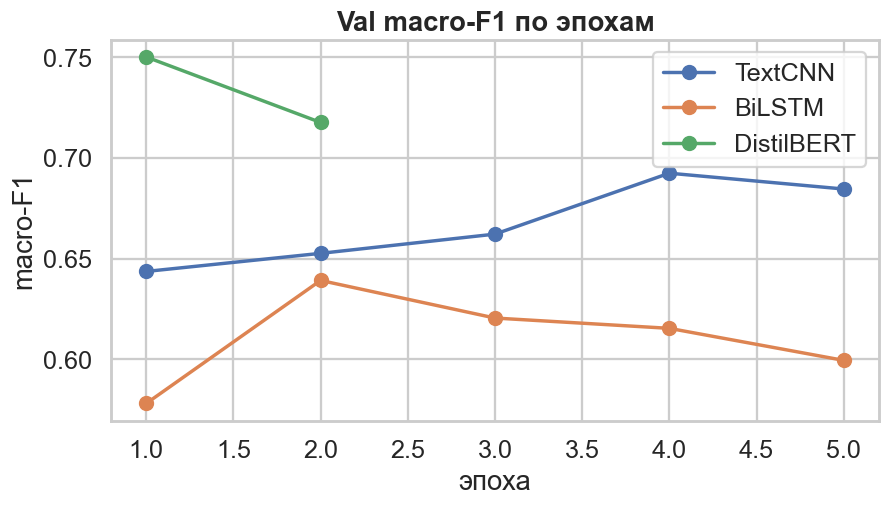

In [8]:
rows = []
for name, r in results.items():
    f1pc = f1_score(r["gts"], r["preds"], average=None)
    rows.append({"модель": name, "параметры": r["params"],
                 "время обуч., с": round(r["time"], 1),
                 "test accuracy": accuracy_score(r["gts"], r["preds"]),
                 "test macro-F1": f1_score(r["gts"], r["preds"], average="macro"),
                 **{f"F1·{l}": v for l, v in zip(LABELS, f1pc)}})
comp = pd.DataFrame(rows).set_index("модель")
display(comp.style.format({"параметры": "{:,.0f}", "время обуч., с": "{:.0f}",
                           "test accuracy": "{:.3f}", "test macro-F1": "{:.3f}",
                           "F1·negative": "{:.3f}", "F1·neutral": "{:.3f}", "F1·positive": "{:.3f}"}))

# Кривые val macro-F1 по эпохам
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, r in results.items():
    h = pd.DataFrame(r["hist"])
    ax.plot(h["epoch"], h["val_macro_f1"], marker="o", label=name)
ax.set_title("Val macro-F1 по эпохам"); ax.set_xlabel("эпоха"); ax.set_ylabel("macro-F1"); ax.legend()
savefig("val_f1_curves"); plt.show()

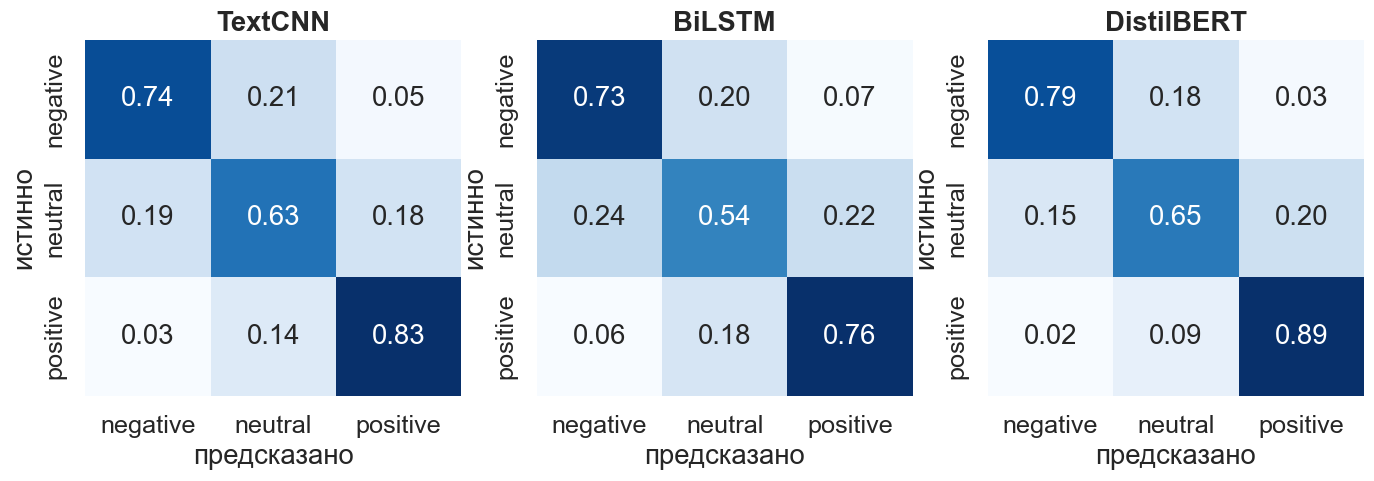

Лучшая по macro-F1: DistilBERT (0.742)


In [9]:
# Матрицы ошибок на тесте
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.2))
if len(results) == 1: axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["gts"], r["preds"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(name); ax.set_xlabel("предсказано"); ax.set_ylabel("истинно")
savefig("confusion_matrices"); plt.show()

best = comp["test macro-F1"].idxmax()
print(f"Лучшая по macro-F1: {best} ({comp.loc[best,'test macro-F1']:.3f})")

## 8. Выводы

Сравнение проведено на одних данных и разбиении, с одинаковой взвешенной функцией потерь, поэтому
различия отражают **свойства архитектур**, а не условия обучения. Ключевые наблюдения (числа — в
таблице и на графиках выше):

- **TextCNN** — самый дешёвый и быстрый; на коротких отзывах ключевые n-граммы («delicious»,
  «worst», «rude») уже дают сильный сигнал, поэтому baseline получается достойным.
- **BiLSTM** — учитывает порядок и более длинные зависимости (отрицания, обороты), но дороже по
  времени; выигрыш над CNN зависит от длины и объёма данных.
- **DistilBERT** — за счёт предобучения и контекстных представлений обычно даёт лучший **macro-F1**,
  особенно на трудном классе *neutral* (3★), где лексических маркеров мало; цена — на порядок больше
  параметров и времени, даже на ограниченном train-сабсете.

**Что это даёт бизнесу.** Лучшая модель идёт в продакшн-сигнал тональности; на её основе строятся
аспектная разбивка, детектор «текст↔оценка» и разметка tips без звёзд. Если важны скорость и
дешевизна инференса (потоковая обработка миллионов отзывов) — разумен компромисс CNN/LSTM; если
важна максимальная точность на спорных отзывах — трансформер.

*Воспроизводимость и логирование:* при `ENABLE_LOGGING=true` метрики каждого рана (параметры,
история по эпохам, метрики на тесте) пишутся в `reports/runs/<model>.json`, а при
`ENABLE_ARTIFACTS=true` — графики в `artifacts/` и веса моделей в `artifacts/models/` (артефакт,
позволяющий воспроизвести предсказания без переобучения).